## 2.1/ Tiền xử lý dữ liệu ảnh số

In [1]:
# Chạy 1 lần, sau đó có thể comment lại
import sys
import subprocess
subprocess.check_call([sys.executable, '-m', 'pip', 'install',
    'imagehash', 'scikit-image', 'scikit-learn',
    'scipy', 'tqdm', 'matplotlib', 'seaborn', 'opencv-python', '-q'])
print('✅ Cài đặt hoàn tất!')

✅ Cài đặt hoàn tất!


In [2]:
import zipfile
import os
from tqdm import tqdm

EXTRACT_DIR = 'data/raw/New Plant Disease'

# Kiểm tra cấu trúc thư mục
MAX_DISPLAY_DEPTH = 4  # Chỉnh số này để xem sâu hơn/nông hơn

print('\nCấu trúc thư mục:')
for root, dirs, files in os.walk(EXTRACT_DIR):
    depth = root.replace(EXTRACT_DIR, '').count(os.sep)
    if depth >= MAX_DISPLAY_DEPTH:
        dirs.clear()  # Ngăn os.walk đi sâu hơn, nhưng KHÔNG break
        continue
    indent = '  ' * depth
    print(f'{indent}📁 {os.path.basename(root)}/')


Cấu trúc thư mục:
📁 New Plant Disease/
  📁 New Plant Diseases Dataset(Augmented)/
    📁 New Plant Diseases Dataset(Augmented)/
      📁 train/
      📁 valid/
  📁 test/
    📁 test/


In [3]:
import os, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
from PIL import Image
import imagehash
from tqdm import tqdm
from collections import defaultdict
from scipy import stats
from scipy.stats import ks_2samp, f_oneway
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage import filters, feature
warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# ── Đường dẫn gốc dataset ────────────────────────────────────────────────────
DATASET_PATH = 'data/raw/New Plant Disease/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train'

# ── Bước 1: Quét toàn bộ lớp có trong dataset ───────────────────────────────
if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f'❌ Không tìm thấy: {DATASET_PATH}')

all_class_dirs = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d))
])
n_total_classes = len(all_class_dirs)

# ── Bước 2: Lọc ra các lớp Tomato ────────────────────────────────────────────
CLASS_NAMES = sorted([
    d for d in all_class_dirs
    if d.lower().startswith('tomato')
])
N_CLASSES = len(CLASS_NAMES)

# ── Bước 3: In báo cáo ───────────────────────────────────────────────────────
print(f'📁 Dataset có {n_total_classes} lớp')
print(f'   ✅ Chỉ lấy {N_CLASSES} lớp Tomato để phân tích')
for cls in CLASS_NAMES:
    print(f'      • {cls}')

# ── Bước 4: Cấu hình các biến còn lại ────────────────────────────────────────
le = LabelEncoder()
le.fit(CLASS_NAMES)

CLASS_COLORS = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
][:N_CLASSES]

CLASS_MAP        = {name: i for i, name in enumerate(CLASS_NAMES)}
MAX_SAMPLE       = 5000
MAX_PER_CLASS    = 500
N_CLASSES_SHOW   = N_CLASSES
IMG_SIZE_DEFAULT = (128, 128)
IMG_EXTENSIONS   = ('.jpg', '.jpeg', '.png')

os.makedirs('outputs', exist_ok=True)

print(f'\n   ✅ Cấu hình hoàn tất. Bắt đầu phân tích...')

📁 Dataset có 38 lớp
   ✅ Chỉ lấy 10 lớp Tomato để phân tích
      • Tomato___Bacterial_spot
      • Tomato___Early_blight
      • Tomato___Late_blight
      • Tomato___Leaf_Mold
      • Tomato___Septoria_leaf_spot
      • Tomato___Spider_mites Two-spotted_spider_mite
      • Tomato___Target_Spot
      • Tomato___Tomato_Yellow_Leaf_Curl_Virus
      • Tomato___Tomato_mosaic_virus
      • Tomato___healthy

   ✅ Cấu hình hoàn tất. Bắt đầu phân tích...


In [4]:
# ĐỌC CẤU TRÚC DỮ LIỆU — quét toàn bộ train / valid / test
from collections import defaultdict
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

IMAGE_EXTS = ('.jpg', '.jpeg', '.png')
ROOT_PATH_AUGMENTED = os.path.dirname(DATASET_PATH)          # .../Augmented/ (train + valid)
ROOT_PATH_TEST      = os.path.dirname(os.path.dirname(os.path.dirname(DATASET_PATH)))

# ─────────────────────────────────────────────────────────────────────────────
def count_images_in_dir(folder: str) -> int:
    """Đếm số ảnh hợp lệ (không rỗng) trong một thư mục."""
    count = 0
    for f in os.listdir(folder):
        if f.lower().endswith(IMAGE_EXTS):
            try:
                if os.path.getsize(os.path.join(folder, f)) > 0:
                    count += 1
            except OSError:
                pass
    return count

# ─────────────────────────────────────────────────────────────────────────────
# Lưu path ảnh theo split và class
# Structure: all_image_paths[split][class] = [path1, path2, ...]
# Chỉ train + valid mới có breakdown theo class
# ─────────────────────────────────────────────────────────────────────────────
all_image_paths: dict[str, dict[str, list[str]]] = {
    'train': {},
    'valid': {},
}

split_totals: dict[str, int] = {}

# ── TRAIN và VALID (có subfolder theo class) ──────────────────────────────────
for split in ['train', 'valid']:
    split_path = os.path.join(ROOT_PATH_AUGMENTED, split)
    if not os.path.isdir(split_path):
        print(f'⚠️  Không tìm thấy: {split_path}')
        split_totals[split] = 0
        continue

    print(f'\n📂 {split.upper()}')
    print('─' * 60)
    split_total = 0

    for cls in CLASS_NAMES:
        cls_path = os.path.join(split_path, cls)
        if not os.path.isdir(cls_path):
            all_image_paths[split][cls] = []
            continue

        paths = [
            os.path.join(cls_path, f)
            for f in os.listdir(cls_path)
            if f.lower().endswith(IMAGE_EXTS)
            and os.path.getsize(os.path.join(cls_path, f)) > 0
        ]
        all_image_paths[split][cls] = paths
        n = len(paths)
        split_total += n
        print(f'  {cls:<52}  {n:>6,} ảnh')

    split_totals[split] = split_total
    print(f'  {"── Tổng":<52}  {split_total:>6,} ảnh')

    # Giữ lại class_image_paths trỏ vào train để tương thích các cell sau
    if split == 'train':
        class_image_paths = all_image_paths['train']

# ── TEST (chỉ đếm tổng, lọc file có "tomato" trong tên) ──────────────────────
test_path = os.path.join(ROOT_PATH_TEST, 'test', 'test')
test_total = 0

if os.path.isdir(test_path):
    for f in os.listdir(test_path):
        if not f.lower().endswith(IMAGE_EXTS):
            continue
        if 'tomato' not in f.lower():
            continue
        try:
            if os.path.getsize(os.path.join(test_path, f)) > 0:
                test_total += 1
        except OSError:
            pass
else:
    print(f'⚠️  Không tìm thấy: {test_path}')

split_totals['test'] = test_total

# ── TỔNG KẾT ──────────────────────────────────────────────────────────────────
grand_total = sum(split_totals.values())
print(f'\n{"═" * 60}')
print(f'  {"SPLIT":<20}  {"SỐ ẢNH TOMATO":>15}  {"TỈ LỆ":>8}')
print(f'{"─" * 60}')
for split, n in split_totals.items():
    pct = n / grand_total * 100 if grand_total > 0 else 0
    print(f'  {split.upper():<20}  {n:>15,}  {pct:>7.1f}%')
print(f'{"─" * 60}')
print(f'  {"TỔNG CỘNG":<20}  {grand_total:>15,}  {"100.0%":>8}')
print(f'{"═" * 60}')

print(f'\n✅ Đã lưu all_image_paths với 2 splits: train / valid')


📂 TRAIN
────────────────────────────────────────────────────────────
  Tomato___Bacterial_spot                                1,702 ảnh
  Tomato___Early_blight                                  1,920 ảnh
  Tomato___Late_blight                                   1,851 ảnh
  Tomato___Leaf_Mold                                     1,882 ảnh
  Tomato___Septoria_leaf_spot                            1,745 ảnh
  Tomato___Spider_mites Two-spotted_spider_mite          1,741 ảnh
  Tomato___Target_Spot                                   1,827 ảnh
  Tomato___Tomato_Yellow_Leaf_Curl_Virus                 1,961 ảnh
  Tomato___Tomato_mosaic_virus                           1,790 ảnh
  Tomato___healthy                                       1,926 ảnh
  ── Tổng                                               18,345 ảnh

📂 VALID
────────────────────────────────────────────────────────────
  Tomato___Bacterial_spot                                  425 ảnh
  Tomato___Early_blight                                 

### 2.1.2/ Phân tích dữ liệu tập thống kê
#### 2.1.2a/ Phân phối giá trị pixel trên toàn tập theo từng kênh màu
Để hiểu đặc trưng màu sắc của tập dữ liệu, ta phân tích phân phối giá trị pixel trên từng kênh màu R, G, B riêng biệt. Mỗi pixel có giá trị nguyên trong đoạn [0, 255], với 0 = tối hoàn toàn và 255 = sáng hoàn toàn trên kênh đó. Hai công cụ trực quan hóa được sử dụng kết hợp:
##### 1/ Histogram chuẩn hóa (Normalized Histogram):
$$\hat{f}(x) = \frac{\text{count}(x \in \text{bin})}{N \cdot h}$$
Trong đó:
- $N$: tổng số pixel được lấy mẫu
- $h$: độ rộng mỗi bin (= 1 vì range là 0–255, chia 256 bins)
- $\text{count}(x \in \text{bin})$: số pixel rơi vào bin chứa $x$
Histogram cho thấy tần suất xuất hiện của từng mức pixel, nhưng bị ảnh hưởng bởi kích thước bin. KDE được dùng để làm mượt.
##### 2/ Kernel Density Estimation (KDE):
KDE ước lượng hàm mật độ xác suất liên tục bằng cách đặt một hàm kernel tại mỗi điểm dữ liệu:
$$\hat{f}(x) = \frac{1}{N \cdot h} \sum_{i=1}^{N} K\!\left(\frac{x - x_i}{h}\right)$$
Trong đó $K$ là Gaussian kernel:
$$K(u) = \frac{1}{\sqrt{2\pi}} e^{-\frac{u^2}{2}}$$
Bandwidth $h$ được chọn tự động theo **quy tắc Silverman**
(tối ưu cho phân phối gần chuẩn):
$$h = 0.9 \cdot \min\!\left(\hat{\sigma},\ 
\frac{\text{IQR}}{1.34}\right) \cdot N^{-1/5}$$
Trong đó:
- $\hat{\sigma}$: độ lệch chuẩn mẫu của dữ liệu
- $\text{IQR}$: khoảng tứ phân vị (Q3 − Q1), dùng để robust
  với outlier
- $N^{-1/5}$: hệ số co bandwidth theo kích thước mẫu —
  mẫu càng lớn, đường KDE càng mịn
##### 3/ Các chỉ số thống kê mô tả
Độ lệch (Skewness) - đo mức độ bất đối xứng của phân phối:
$$\text{Skewness} = \frac{E\left[(X - \mu)^3\right]}{\sigma^3}$$
- Skewness $> 0$: đuôi phải dài hơn (lệch phải)
- Skewness $< 0$: đuôi trái dài hơn (lệch trái)
- $|\text{Skewness}| < 0.5$: phân phối gần đối xứng

Độ nhọn (Excess Kurtosis) — đo mức độ "nhọn" của đỉnh so với phân phối chuẩn:
$$\text{Kurtosis} = \frac{E\left[(X - \mu)^4\right]}{\sigma^4} - 3$$
- Kurtosis $> 0$ (leptokurtic): đỉnh nhọn, đuôi dày
- Kurtosis $< 0$ (platykurtic): đỉnh dẹt, đuôi mỏng
- Kurtosis $= 0$: đúng phân phối chuẩn

Đang đọc 5,000 ảnh mẫu để phân tích pixel...
⚠️  Lưu ý: ảnh được resize về (128, 128) trước khi lấy pixel.
    → Mean được bảo toàn tốt; Std có thể bị underestimate ~10–15% so với ảnh gốc.


Đọc pixel: 100%|██████████████████████████████████████████████████████████████████| 5000/5000 [00:19<00:00, 251.82it/s]


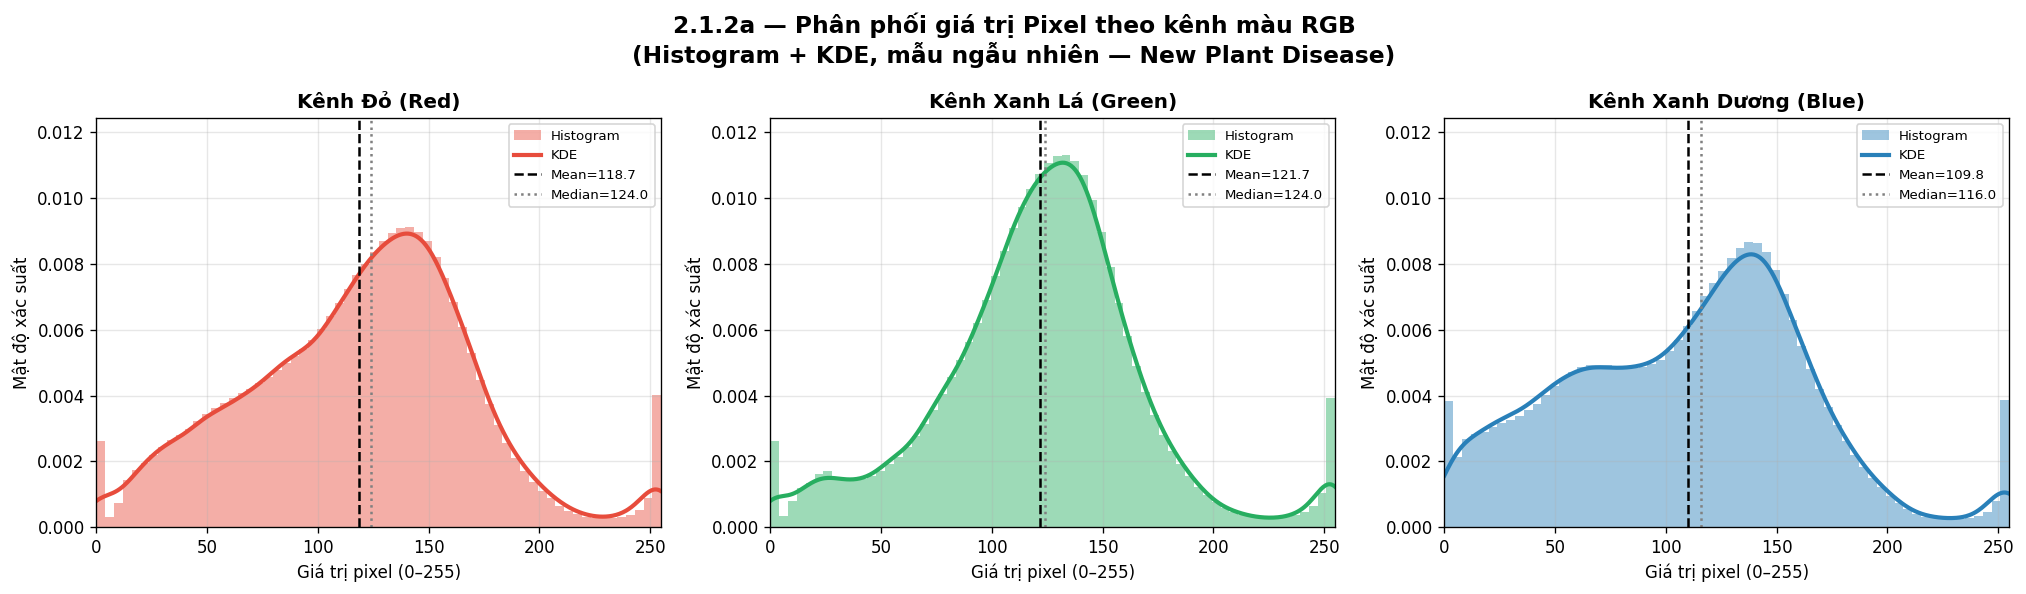


📊 Bảng thống kê pixel theo kênh màu:
      mean  median     std   skew  kurtosis  min    max
R  118.721   124.0  50.873 -0.011     0.012  0.0  255.0
G  121.721   124.0  45.876  0.021     0.973  0.0  255.0
B  109.752   116.0  54.548  0.073    -0.277  0.0  255.0

📌 pixel_mean_R=118.72, pixel_mean_G=121.72, pixel_mean_B=109.75
📌 pixel_std_R=50.87,  pixel_std_G=45.88,  pixel_std_B=54.55


In [5]:
# Phân phối giá trị Pixel theo kênh màu RGB
all_paths = []
for cls, paths in all_image_paths['train'].items():
    all_paths.extend(paths)
all_paths    = np.array(all_paths)
total_images = len(all_paths)

PIXEL_SAMPLE = 5000
sample_paths = np.random.choice(all_paths, min(PIXEL_SAMPLE, total_images), replace=False)
channels = {'R': [], 'G': [], 'B': []}
skipped_pixel = 0

print(f'Đang đọc {len(sample_paths):,} ảnh mẫu để phân tích pixel...')
print(f'⚠️  Lưu ý: ảnh được resize về {IMG_SIZE_DEFAULT} trước khi lấy pixel.')
print(f'    → Mean được bảo toàn tốt; Std có thể bị underestimate ~10–15% so với ảnh gốc.')

for path in tqdm(sample_paths, desc='Đọc pixel'):
    try:
        img = Image.open(path).convert('RGB').resize(IMG_SIZE_DEFAULT, Image.LANCZOS)
        arr = np.array(img)
        if arr.shape != (IMG_SIZE_DEFAULT[0], IMG_SIZE_DEFAULT[1], 3):
            raise ValueError(f'Shape không hợp lệ: {arr.shape}')
        channels['R'].append(arr[:, :, 0].ravel())
        channels['G'].append(arr[:, :, 1].ravel())
        channels['B'].append(arr[:, :, 2].ravel())
    except Exception as e:
        skipped_pixel += 1
        print(f'⚠️  Bỏ qua ảnh lỗi: {os.path.basename(path)} ({e})')

if skipped_pixel > 0:
    print(f'\n⚠️  Tổng số ảnh bị bỏ qua: {skipped_pixel}')

for k in channels:
    channels[k] = np.concatenate(channels[k])

# ── PASS 1: Tính trước KDE + stats cho cả 3 kênh ─────────────────────────────
# Mục đích: xác định y_max chung TRƯỚC khi vẽ, tránh mỗi subplot tự scale riêng
color_cfg = {
    'R': ('#e74c3c', 'Kênh Đỏ (Red)'),
    'G': ('#27ae60', 'Kênh Xanh Lá (Green)'),
    'B': ('#2980b9', 'Kênh Xanh Dương (Blue)'),
}
pixel_stats  = {}
kde_cache    = {}   # lưu (kde_obj, x_kde, kde_values) để dùng lại ở PASS 2
hist_max_all = []   # đỉnh histogram density của mỗi kênh
kde_max_all  = []   # đỉnh KDE density của mỗi kênh

for ch in ['R', 'G', 'B']:
    data = channels[ch].astype(np.float32)

    # Histogram density peak
    hist_counts, bin_edges = np.histogram(data, bins=64, range=(0, 255), density=True)
    hist_max_all.append(hist_counts.max())

    # KDE peak
    kde_sample = np.random.choice(data, size=min(30_000, len(data)), replace=False)
    kde_obj    = stats.gaussian_kde(kde_sample, bw_method='silverman')
    x_kde      = np.linspace(0, 255, 512)
    kde_vals   = kde_obj(x_kde)
    kde_max_all.append(kde_vals.max())

    kde_cache[ch] = (kde_obj, x_kde, kde_vals)

    pixel_stats[ch] = {
        'mean':     float(np.mean(data)),
        'median':   float(np.median(data)),
        'std':      float(np.std(data)),
        'skew':     float(stats.skew(kde_sample)),
        'kurtosis': float(stats.kurtosis(kde_sample)),
        'min':      float(np.min(data)),
        'max':      float(np.max(data)),
    }

# Y_MAX chung = đỉnh cao nhất trong tất cả kênh, thêm 10% lề trên
y_max_global = max(max(hist_max_all), max(kde_max_all)) * 1.10

# ── PASS 2: Vẽ với trục Y đồng nhất ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(
    '2.1.2a — Phân phối giá trị Pixel theo kênh màu RGB\n'
    '(Histogram + KDE, mẫu ngẫu nhiên — New Plant Disease)',
    fontsize=14, fontweight='bold'
)

for ax, (ch, (color, label)) in zip(axes, color_cfg.items()):
    data              = channels[ch].astype(np.float32)
    _, x_kde, kde_vals = kde_cache[ch]
    mean_v            = pixel_stats[ch]['mean']
    med_v             = pixel_stats[ch]['median']

    ax.hist(data, bins=64, range=(0, 255),
            color=color, alpha=0.45, density=True, label='Histogram')
    ax.plot(x_kde, kde_vals, color=color, lw=2.5, label='KDE')
    ax.axvline(mean_v, color='black', ls='--', lw=1.5, label=f'Mean={mean_v:.1f}')
    ax.axvline(med_v,  color='gray',  ls=':',  lw=1.5, label=f'Median={med_v:.1f}')

    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Giá trị pixel (0–255)')
    ax.set_ylabel('Mật độ xác suất')
    ax.set_xlim(0, 255)
    ax.set_ylim(0, y_max_global)   # ← ĐIỂM THAY ĐỔI DUY NHẤT SO VỚI CODE CŨ
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/2_1_2a_pixel_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# ── In bảng thống kê ──────────────────────────────────────────────────────────
pixel_stats_df = pd.DataFrame(pixel_stats).T
print('\n📊 Bảng thống kê pixel theo kênh màu:')
print(pixel_stats_df.round(3).to_string())

pixel_mean_R = pixel_stats['R']['mean'];  pixel_mean_G = pixel_stats['G']['mean']
pixel_mean_B = pixel_stats['B']['mean'];  pixel_std_R  = pixel_stats['R']['std']
pixel_std_G  = pixel_stats['G']['std'];   pixel_std_B  = pixel_stats['B']['std']
print(f'\n📌 pixel_mean_R={pixel_mean_R:.2f}, pixel_mean_G={pixel_mean_G:.2f}, pixel_mean_B={pixel_mean_B:.2f}')
print(f'📌 pixel_std_R={pixel_std_R:.2f},  pixel_std_G={pixel_std_G:.2f},  pixel_std_B={pixel_std_B:.2f}')

#### Phân tích theo kênh

**Kênh G (Green) — Mean = 121.72, Std = 45.88, Kurtosis = 0.973**

Kênh G có giá trị mean cao nhất trong 3 kênh, phù hợp với đặc trưng điển hình của tập dữ liệu lá cây — lá xanh hấp thụ mạnh ánh sáng đỏ và xanh dương nhưng phản xạ mạnh ánh sáng xanh lá. Kurtosis dương (+0.973, leptokurtic) cho thấy phân phối có đỉnh nhọn hơn phân phối chuẩn: phần lớn pixel tập trung quanh một vùng giá trị trung tâm (lá xanh khỏe mạnh), nhưng đuôi phân phối dày hơn bình thường — phản ánh sự hiện diện của vùng lá bị bệnh, đốm hoại tử, hoặc nền đất/ánh sáng mạnh.

**Kênh B (Blue) — Mean = 109.75, Std = 54.55, Kurtosis = −0.277**

Kênh B có mean thấp nhất và độ lệch chuẩn cao nhất trong ba kênh (Std = 54.55). Kurtosis âm (platykurtic) cho thấy phân phối dẹt hơn phân phối chuẩn — pixel xanh dương phân tán tương đối đều trên dải [0, 255] thay vì tập trung mạnh quanh một đỉnh. Điều này thường do ánh sáng ngoài trời (bầu trời, nền môi trường) đóng góp giá trị B cao ở một số ảnh.

**Kênh R (Red) — Mean = 118.72, Std = 50.87, Kurtosis = 0.012**

Kênh R có kurtosis gần 0 (mesokurtic), cho thấy phân phối rất gần với phân phối chuẩn. Độ lệch chuẩn cao (Std = 50.87) phản ánh sự đa dạng về màu sắc giữa các lớp bệnh: lá xanh khỏe có R thấp, trong khi lá vàng (Early Blight, Leaf Mold) hay vùng hoại tử đỏ (Bacterial Spot) đóng góp R cao.

#### Nhận xét về Skewness

Tất cả ba kênh đều có |Skewness| < 0.5 (R = −0.011, G = +0.021, B = +0.073), tức phân phối gần đối xứng. Điều này cho thấy **cả Z-score lẫn Min-Max normalization đều có thể áp dụng được**. Tuy nhiên, do Std khác nhau đáng kể giữa các kênh (45.88 vs 54.55), nên **per-channel normalization** là lựa chọn ưu tiên để tránh một kênh bị chi phối không cân xứng.

#### Kết luận

Ba kênh RGB có phân phối không đồng nhất về cả mean lẫn độ phân tán, nhưng đều đối xứng (Skewness ≈ 0). Kênh G mang đặc trưng thực vật rõ nhất và có độ phân tán thấp nhất. Đường KDE làm lộ rõ tính đa đỉnh (multimodality) tiềm ẩn — dấu hiệu tập dữ liệu chứa nhiều lớp bệnh với màu sắc lá khác nhau, xác nhận tính đa dạng cần thiết cho bài toán phân loại đa lớp.

#### 2.1.2.b/ Phân tích mất cân bằng lớp (class imbalance)
Class imbalance (mất cân bằng lớp) xảy ra khi số lượng mẫu giữa các lớp chênh lệch đáng kể. Đây là vấn đề quan trọng cần phát hiện trước khi huấn luyện mô hình vì mô hình có xu hướng thiên vị (bias) về phía lớp có nhiều mẫu hơn, dẫn đến hiệu năng kém trên lớp thiểu số.
##### 1/ Tỉ lệ phần trăm mỗi lớp
$$p_i = \frac{n_i}{\displaystyle\sum_{j=1}^{C} n_j} \times 100\%$$
Trong đó:
- $n_i$: số ảnh của lớp thứ $i$
- $C$: tổng số lớp (= 38)
- $p_i$: tỉ lệ phần trăm của lớp $i$ so với toàn tập
##### 2/ Tiêu chí phát hiện mất cân bằng nghiêm trọng
Một tập dữ liệu được coi là **mất cân bằng nghiêm trọng** nếu:
$$\text{Imbalance Ratio} = \frac{\max_i(n_i)}{\min_i(n_i)} > 3$$
Tức là lớp nhiều ảnh nhất gấp hơn 3 lần lớp ít ảnh nhất. Ngưỡng cụ thể được tính là:
$$\text{Threshold}_{3\times} = \min_i(n_i) \times 3$$
Bất kỳ lớp nào có $n_i > \text{Threshold}_{3\times}$ đều được đánh dấu là lớp gây mất cân bằng.

──────────────────────────────────────────────────────────
  Mã    Tên đầy đủ
──────────────────────────────────────────────────────────
  TBS   Tomato___Bacterial_spot
  TEB   Tomato___Early_blight
  THY   Tomato___healthy
  TLB   Tomato___Late_blight
  TLM   Tomato___Leaf_Mold
  TMV   Tomato___Tomato_mosaic_virus
  TSM   Tomato___Spider_mites Two-spotted_spider_mite
  TSS   Tomato___Septoria_leaf_spot
  TTS   Tomato___Target_Spot
  TYL   Tomato___Tomato_Yellow_Leaf_Curl_Virus
──────────────────────────────────────────────────────────

  TẦNG 1 — TOÀN BỘ DATASET (train + valid)
  Tổng ảnh (train+valid): 22,930
  Tổng ảnh test         : 16  (không có breakdown theo class)
  Số lớp                : 10
  Lớp nhiều nhất        : 2,451  (10.7%)
  Lớp ít nhất           : 2,127  (9.3%)
  Trung bình / lớp      : 2,293.0
  Imbalance Ratio       : 1.15x
  Ngưỡng 3x min         : 6,381
  Mất cân bằng >= 3x    : KHÔNG

  Mã       Tổng ảnh   Tỉ lệ (%)   Ratio/min   Vượt 3x?
-----------------------

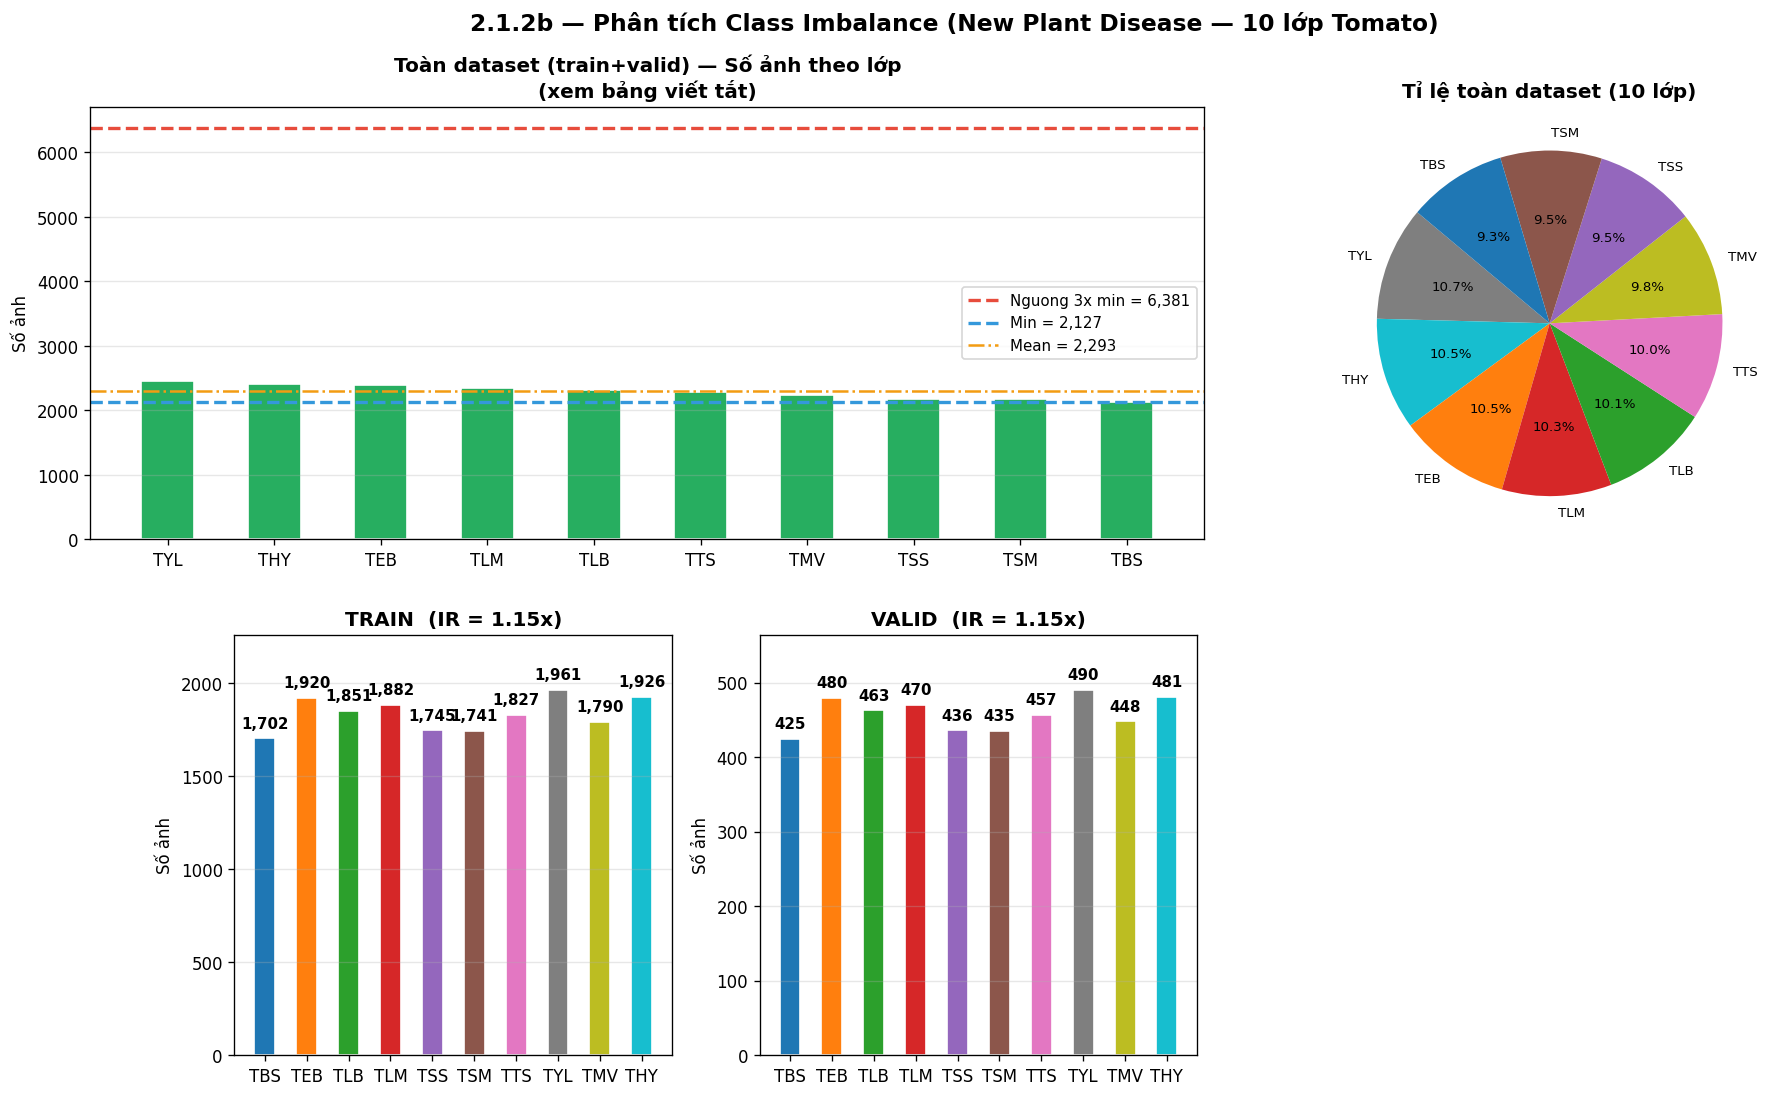


📌 class_dirs = ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']
📌 Biến class_counts (train) đã lưu — dùng cho các cell tiếp theo.


In [6]:
# ══════════════════════════════════════════════════════════════════════
# 2.1.2b — PHÂN TÍCH MẤT CÂN BẰNG LỚP
# Tầng 1: Toàn bộ dataset  |  Tầng 2: Từng split (train/valid)
# ══════════════════════════════════════════════════════════════════════

# ── BẢNG VIẾT TẮT — in trước toàn bộ phân tích ───────────────────────
ABBR_MAP: dict[str, str] = {
    'Tomato___Bacterial_spot'                          : 'TBS',
    'Tomato___Early_blight'                            : 'TEB',
    'Tomato___Late_blight'                             : 'TLB',
    'Tomato___Leaf_Mold'                               : 'TLM',
    'Tomato___Septoria_leaf_spot'                      : 'TSS',
    'Tomato___Spider_mites Two-spotted_spider_mite'    : 'TSM',
    'Tomato___Target_Spot'                             : 'TTS',
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus'           : 'TYL',
    'Tomato___Tomato_mosaic_virus'                     : 'TMV',
    'Tomato___healthy'                                 : 'THY',
}

def abbr(cls: str) -> str:
    """Trả về mã viết tắt; fallback về 3 ký tự đầu nếu không có trong map."""
    return ABBR_MAP.get(cls, cls[:3].upper())

# In bảng legend
abbr_w    = max(len(v) for v in ABBR_MAP.values())
fullname_w = max(len(k) for k in ABBR_MAP.keys())
sep_abbr  = '─' * (abbr_w + fullname_w + 10)

print(sep_abbr)
print(f'  {"Mã":^{abbr_w}}   Tên đầy đủ')
print(sep_abbr)
for full, short in sorted(ABBR_MAP.items(), key=lambda x: x[1]):
    print(f'  {short:^{abbr_w}}   {full}')
print(sep_abbr)
print()

# ── TẦNG 1: Tổng hợp toàn bộ dataset (train + valid) ─────────────────
global_counts = defaultdict(int)
for split in ['train', 'valid']:
    for cls, paths in all_image_paths[split].items():
        global_counts[cls] += len(paths)

global_counts  = dict(sorted(global_counts.items(), key=lambda x: x[1], reverse=True))
total_all      = sum(global_counts.values())
min_g          = min(global_counts.values())
max_g          = max(global_counts.values())
mean_g         = total_all / len(global_counts)
ir_global      = max_g / min_g
threshold_3x_g = min_g * 3
is_imbal_g     = ir_global > 3.0

print('=' * 62)
print('  TẦNG 1 — TOÀN BỘ DATASET (train + valid)')
print('=' * 62)
print(f'  Tổng ảnh (train+valid): {total_all:,}')
if 'test' in split_totals:
    print(f'  Tổng ảnh test         : {split_totals["test"]:,}  (không có breakdown theo class)')
print(f'  Số lớp                : {len(global_counts)}')
print(f'  Lớp nhiều nhất        : {max_g:,}  ({max_g/total_all*100:.1f}%)')
print(f'  Lớp ít nhất           : {min_g:,}  ({min_g/total_all*100:.1f}%)')
print(f'  Trung bình / lớp      : {mean_g:,.1f}')
print(f'  Imbalance Ratio       : {ir_global:.2f}x')
print(f'  Ngưỡng 3x min         : {threshold_3x_g:,}')
imbal_status = 'CÓ — cần xử lý' if is_imbal_g else 'KHÔNG'
print(f'  Mất cân bằng >= 3x    : {imbal_status}')

# Bảng Tầng 1 — dùng mã viết tắt
print()
abbr_col_w = max(len(abbr(c)) for c in global_counts) + 2
header_t1  = (f'  {"Mã":<{abbr_col_w}}  {"Tổng ảnh":>10}'
              f'  {"Tỉ lệ (%)":>10}  {"Ratio/min":>10}  {"Vượt 3x?":>9}')
sep_t1 = '-' * len(header_t1)
print(header_t1)
print(sep_t1)
for cls, cnt in global_counts.items():
    pct   = cnt / total_all * 100
    ratio = cnt / min_g
    flag  = '[!] YES' if cnt > threshold_3x_g else '    NO '
    print(f'  {abbr(cls):<{abbr_col_w}}  {cnt:>10,}'
          f'  {pct:>9.2f}%  {ratio:>10.2f}  {flag:>9}')
print(sep_t1)

# ── TẦNG 2: Theo từng split (train / valid) ───────────────────────────
print()
print('=' * 62)
print('  TẦNG 2 — THEO TỪNG SPLIT (train / valid)')
print('=' * 62)

all_cls_names = sorted({
    cls
    for split in ['train', 'valid']
    for cls in all_image_paths[split].keys()
})

split_rows = []

for split in ['train', 'valid']:
    if split not in all_image_paths:
        continue
    cls_dict  = all_image_paths[split]
    total_sp  = sum(len(v) for v in cls_dict.values())
    min_sp    = min(len(v) for v in cls_dict.values())
    max_sp    = max(len(v) for v in cls_dict.values())
    ir_sp     = max_sp / min_sp if min_sp > 0 else float('inf')
    is_imb_sp = ir_sp > 3.0

    role = {
        'train': 'Học  - cần xử lý nếu IR > 3',
        'valid': 'Eval - KHÔNG resampling     ',
    }[split]

    status_str = 'Imbalanced (IR > 3)' if is_imb_sp else 'Balanced           '
    print(f'\n  [{split.upper()}]  IR = {ir_sp:.2f}x  |  {status_str}')

    # In detail — dùng mã viết tắt
    for cls, paths in sorted(cls_dict.items(), key=lambda x: -len(x[1])):
        cnt = len(paths)
        pct = cnt / total_sp * 100
        bar = '#' * int(cnt / max_sp * 25)
        print(f'    {abbr(cls):<5}: {cnt:>6,}  ({pct:5.1f}%)  [{bar:<25}]')

    if is_imb_sp and split == 'train':
        print('    => Dùng SMOTE hoặc class_weight khi huấn luyện')
    elif is_imb_sp:
        print('    => Dùng F1-macro / AUC-ROC thay vì Accuracy')

    row = {'Split': split, 'Vai trò': role.strip()}
    for c in all_cls_names:
        row[abbr(c)] = len(cls_dict.get(c, []))   # ← key là mã viết tắt
    row['IR (x)']     = round(ir_sp, 2)
    row['Imbalanced'] = 'YES' if is_imb_sp else 'NO '
    split_rows.append(row)

# Bảng tổng hợp splits — hoàn toàn dùng mã viết tắt
abbr_names = [abbr(c) for c in all_cls_names]   # list mã theo thứ tự all_cls_names
col_w      = max(len(a) for a in abbr_names) + 2
role_w     = max(len(r['Vai trò']) for r in split_rows) + 1

print()
print('=' * 62)
print('  BẢNG TỔNG HỢP THEO SPLIT  (xem bảng viết tắt ở đầu cell)')
print('=' * 62)

header_t2 = f'  {"Split":<7}  {"Vai trò":<{role_w}}'
for a in abbr_names:
    header_t2 += f'  {a:>{col_w}}'
header_t2 += f'  {"IR(x)":>6}  {"Imbal?":>6}'
sep_t2 = '-' * len(header_t2)

print(header_t2)
print(sep_t2)
for row in split_rows:
    line = f'  {row["Split"]:<7}  {row["Vai trò"]:<{role_w}}'
    for a in abbr_names:
        line += f'  {row[a]:>{col_w},}'
    line += f'  {row["IR (x)"]:>6.2f}  {row["Imbalanced"]:>6}'
    print(line)
print(sep_t2)

print('''
  Ghi chú:
    train : Duy nhất split được phép resampling (SMOTE / class_weight)
    valid : Tune hyperparameter — giữ nguyên phân phối gốc
    IR>3x trên valid: chọn F1-macro và AUC-ROC thay vì Accuracy
''')

df_split_summary = pd.DataFrame(split_rows)

# ── BIỂU ĐỒ ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('2.1.2b — Phân tích Class Imbalance (New Plant Disease — 10 lớp Tomato)',
             fontsize=14, fontweight='bold')

fig.delaxes(axes[0, 0])
fig.delaxes(axes[0, 1])
fig.delaxes(axes[0, 2])
ax_bar = fig.add_axes([0.05, 0.54, 0.58, 0.36])
ax_pie = fig.add_axes([0.67, 0.54, 0.28, 0.36])

# Bar chart toàn dataset — nhãn X dùng mã viết tắt
abbr_labels_g = [abbr(c) for c in global_counts.keys()]
clrs_g = ['#e74c3c' if v > threshold_3x_g else '#27ae60'
          for v in global_counts.values()]
ax_bar.bar(abbr_labels_g, list(global_counts.values()),
           color=clrs_g, edgecolor='white', width=0.5)
ax_bar.axhline(threshold_3x_g, color='#e74c3c', ls='--', lw=2,
               label=f'Nguong 3x min = {threshold_3x_g:,}')
ax_bar.axhline(min_g,  color='#3498db', ls='--', lw=2,
               label=f'Min = {min_g:,}')
ax_bar.axhline(mean_g, color='#f39c12', ls='-.', lw=1.5,
               label=f'Mean = {mean_g:,.0f}')
ax_bar.set_title('Toàn dataset (train+valid) — Số ảnh theo lớp\n(xem bảng viết tắt)',
                 fontweight='bold')
ax_bar.set_ylabel('Số ảnh')
ax_bar.legend(fontsize=9)
ax_bar.grid(axis='y', alpha=0.3)

# Pie chart — nhãn dùng mã viết tắt
ax_pie.pie(
    global_counts.values(),
    labels=[abbr(c) for c in global_counts.keys()],
    autopct='%1.1f%%',
    startangle=140,
    colors=[CLASS_COLORS[CLASS_NAMES.index(c)] if c in CLASS_NAMES else '#95a5a6'
            for c in global_counts.keys()],
    textprops={'fontsize': 8},
)
ax_pie.set_title('Tỉ lệ toàn dataset (10 lớp)', fontweight='bold')

# Hàng 2: bar từng split — nhãn X dùng mã viết tắt
split_colors = {cls: CLASS_COLORS[i % len(CLASS_COLORS)]
                for i, cls in enumerate(CLASS_NAMES)}

for col_idx, split in enumerate(['train', 'valid']):
    if split not in all_image_paths:
        continue
    ax       = axes[1, col_idx]
    cls_dict = all_image_paths[split]
    names    = list(cls_dict.keys())
    cnts     = [len(cls_dict[c]) for c in names]
    clrs_sp  = [split_colors.get(n, '#95a5a6') for n in names]
    abbr_x   = [abbr(n) for n in names]          # ← nhãn viết tắt cho trục X

    bars = ax.bar(abbr_x, cnts, color=clrs_sp, edgecolor='white', width=0.5)
    for bar, cnt in zip(bars, cnts):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(cnts) * 0.02,
                f'{cnt:,}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')

    ir_sp = max(cnts) / min(cnts) if min(cnts) > 0 else 0
    ax.set_title(f'{split.upper()}  (IR = {ir_sp:.2f}x)', fontweight='bold')
    ax.set_ylabel('Số ảnh')
    ax.set_ylim(0, max(cnts) * 1.15)
    ax.grid(axis='y', alpha=0.3)

axes[1, 2].set_visible(False)

plt.savefig('outputs/2_1_2b_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Lưu biến cho cell sau ─────────────────────────────────────────────
class_images           = all_image_paths['train']
class_counts           = {cls: len(imgs) for cls, imgs in class_images.items()}
counts_sorted          = dict(sorted(class_counts.items(), key=lambda x: x[1], reverse=True))
total_images_count     = sum(class_counts.values())
min_c                  = min(class_counts.values())
max_c                  = max(class_counts.values())
mean_c                 = total_images_count / len(class_counts)
imbalance_ratio        = max_c / min_c
threshold_3x           = min_c * 3
is_severely_imbalanced = imbalance_ratio > 3.0
class_dirs             = list(class_images.keys())

print(f'\n📌 class_dirs = {class_dirs}')
print(f'📌 Biến class_counts (train) đã lưu — dùng cho các cell tiếp theo.')

#### Đánh giá mức độ cân bằng

Tập dữ liệu *New Plant Disease* (10 lớp Tomato) có phân phối lớp **gần như hoàn toàn cân bằng**. Imbalance Ratio chỉ đạt **1.15×** — tức lớp nhiều nhất (Tomato Yellow Leaf Curl Virus, 2,451 ảnh) chỉ nhiều hơn lớp ít nhất (Bacterial Spot, 2,127 ảnh) khoảng 15%. Con số này thấp hơn rất nhiều so với ngưỡng mất cân bằng nghiêm trọng (IR > 3×). Kết quả nhất quán trên cả tập train (IR = 1.15×) lẫn tập valid (IR = 1.15×), cho thấy việc chia split được thực hiện với stratification tốt.

Đây là đặc điểm của một **tập dữ liệu đã được augment có kiểm soát** (phù hợp với tên dataset "Augmented") — số lượng ảnh được điều chỉnh tương đối đồng đều giữa các lớp thay vì phụ thuộc hoàn toàn vào tần suất tự nhiên của từng loại bệnh.

#### Hệ quả cho thiết kế pipeline

Vì tập dữ liệu **không mất cân bằng**, các biện pháp xử lý đặc biệt như SMOTE, class_weight hay resampling là **không cần thiết** ở bước này. Metric đánh giá mô hình có thể sử dụng Accuracy thông thường mà không cần ưu tiên F1-macro hay AUC-ROC. Tuy nhiên, nếu sau này mở rộng sang toàn bộ 38 lớp gốc của dataset, cần kiểm định lại vì một số lớp cây khác (không phải Tomato) có thể có phân phối khác.

#### 2.1.2.c/ Phát hiện ảnh trùng lặp hoặc gần trùng bằng hàm băm perceptual hash (pHash)
Ảnh trùng lặp (duplicate) hoặc gần trùng (near-duplicate) trong tập huấn luyện gây ra hai vấn đề nghiêm trọng: (1) **data leakage** nếu cùng ảnh xuất hiện ở cả train và test set; (2) **overfitting** do mô hình thấy cùng một mẫu nhiều lần. Perceptual Hash (pHash) phát hiện các ảnh này dựa trên nội dung thị giác, không phụ thuộc vào tên file hay metadata.
##### Thuật toán DCT-based pHash
**Bước 1 — Chuyển Grayscale:**
Loại bỏ thông tin màu sắc, chỉ giữ lại cấu trúc sáng tối:
$$I_{\text{gray}} = \text{cv2.imread}(\text{path},\ \texttt{IMREAD\_GRAYSCALE})$$
**Bước 2 — Resize về kích thước cố định:**
$$I_{\text{resized}} \in \mathbb{R}^{(h \times 4) \times (h \times 4)}$$
Với $h = \texttt{HASH\_SIZE} = 16$, ảnh được resize về $64 \times 64$. Resize trước DCT giúp chuẩn hóa kích thước đầu vào và giảm nhiễu cao tần.

**Bước 3 — Biến đổi DCT-2D (Discrete Cosine Transform):**
$$F(u, v) = \frac{2}{N} C(u)C(v) \sum_{x=0}^{N-1}\sum_{y=0}^{N-1} I(x,y)\cos\frac{(2x+1)u\pi}{2N} \cos\frac{(2y+1)v\pi}{2N}$$
Trong đó $C(k) = \frac{1}{\sqrt{2}}$ nếu $k=0$, ngược lại $C(k) = 1$.

DCT biến đổi ảnh từ không gian pixel sang không gian tần số. **Góc trên-trái** của ma trận DCT chứa các thành phần **low-frequency** — đại diện cho hình dạng tổng thể và màu sắc dominant của ảnh, ít bị ảnh hưởng bởi nhiễu và thay đổi nhỏ.

**Bước 4 — Tạo chuỗi bit hash:**

Lấy vùng $h \times h = 16 \times 16 = 256$ hệ số DCT low-frequency góc trên-trái, so sánh từng hệ số với giá trị median:
$$\text{bit}_{(u,v)} = \begin{cases} 1 & \text{nếu } F(u,v) > \text{median}(F_{\text{low}}) \\ 0 & \text{nếu } F(u,v) \leq \text{median}(F_{\text{low}}) \end{cases}$$
Kết quả là một chuỗi **256 bits** đại diện cho "dấu vân tay thị giác" của ảnh.

**Bước 5 — Hamming Distance:**

Độ tương đồng giữa hai ảnh được đo bằng số bit khác nhau:
$$d_H(h_1, h_2) = \sum_{i=1}^{256} \mathbf{1}\!\left[h_1^{(i)} \neq h_2^{(i)}\right]$$
- $d_H = 0$: hai ảnh **identical** về mặt thị giác
- $d_H \leq 4$: hai ảnh **near-duplicate** (chỉ 1.6% bits khác nhau)
- $d_H > 4$: hai ảnh **khác nhau** về nội dung thị giác


Đang tính pHash (hash_size=16, 256 bits) cho 9,585 ảnh (~45,931,320 cặp)...
⚠️  Quét cross-split (train ∪ valid) để phát hiện data leakage.


pHash: 100%|█████████████████████████████████████████████████████████████████████| 9585/9585 [00:09<00:00, 1034.81it/s]


✅ Tính xong: 9,585 hash hợp lệ (bỏ qua 0 ảnh lỗi)
Đang so sánh 45,931,320 cặp ảnh...


So sánh: 100%|█████████████████████████████████████████████████████████████████████| 9585/9585 [06:19<00:00, 25.27it/s]



  KẾT QUẢ PHÁT HIỆN ẢNH TRÙNG (pHash — cross-split)
  Ảnh được kiểm tra        : 9,585
  Số cặp gần trùng         : 4
    ├─ Intra-split          : 4  (trùng trong cùng split)
    ├─ Cross-split          : 0  (⚠️  data leakage!)
    └─ Exact (dist=0)       : 4
  Ảnh cần loại bỏ          : 4
  Tỉ lệ trùng lặp          : 0.04%
  Tỉ lệ exact duplicate    : 0.04%
  Threshold Hamming        : ≤ 4  (trên 256 bits)


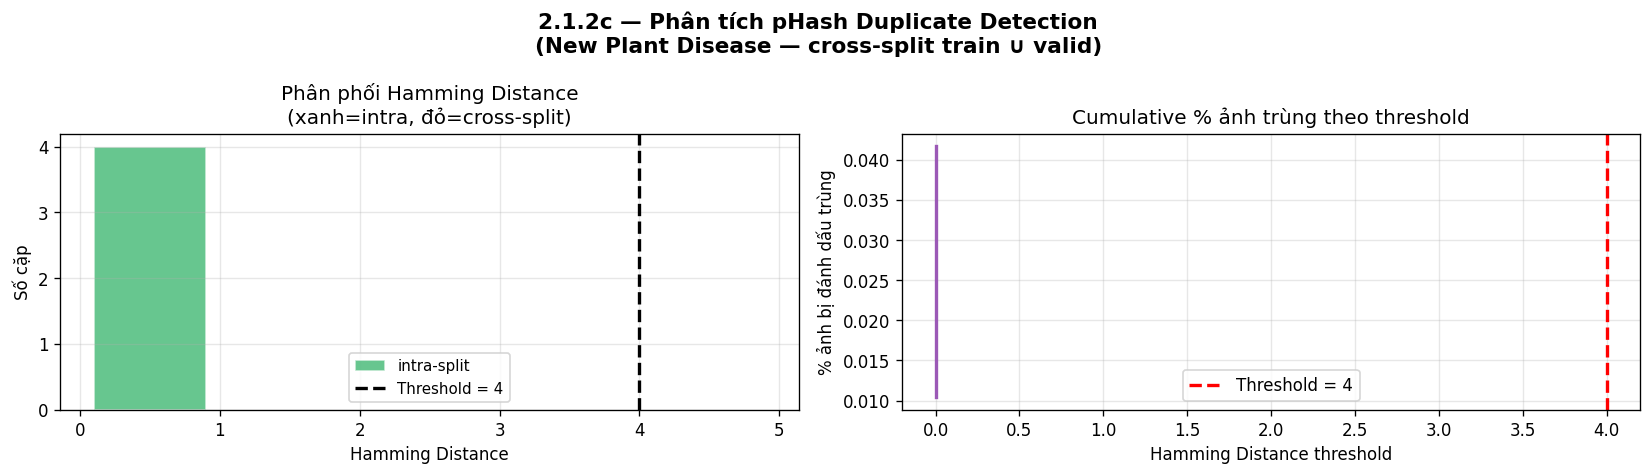

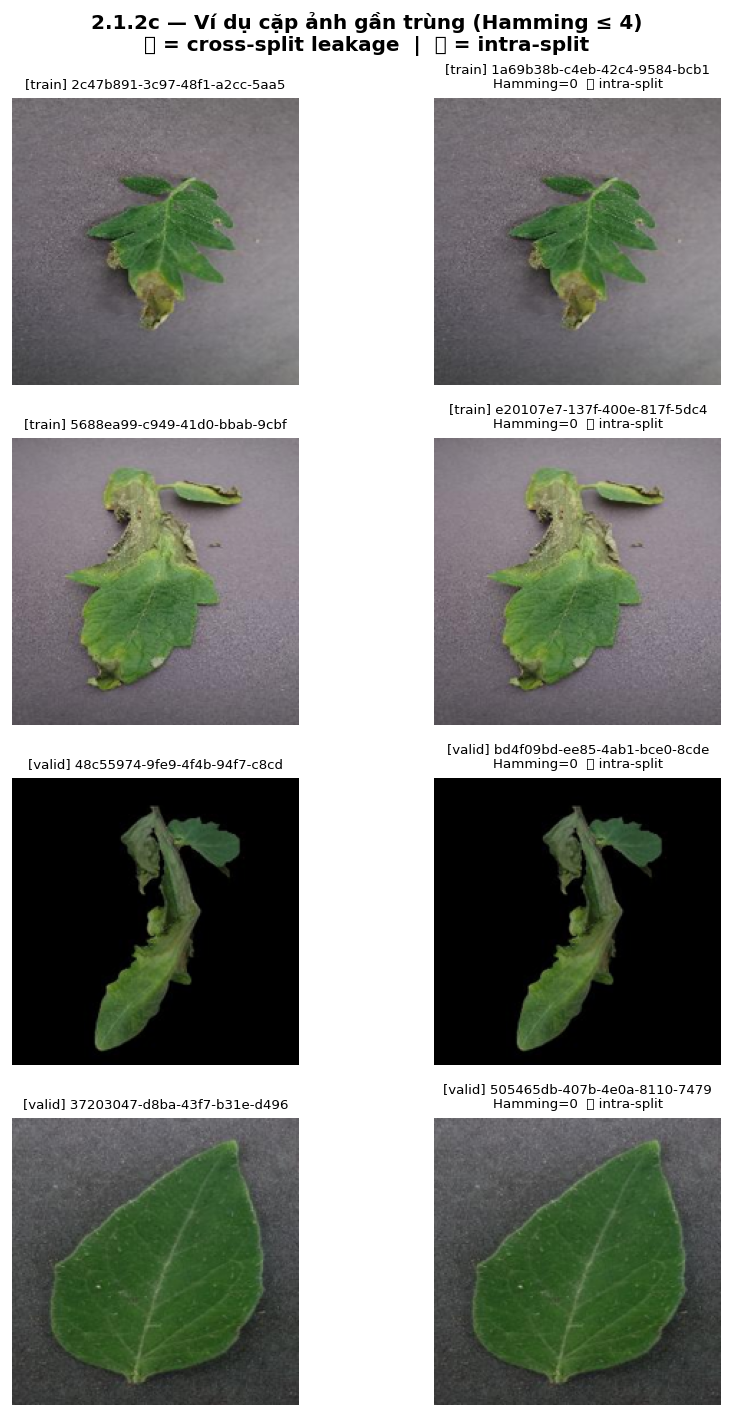


✅ Sau khi loại bỏ: còn 9,581 ảnh sạch (đã loại 4 ảnh trùng)


In [7]:
# Phát hiện ảnh trùng lặp bằng pHash — cross-split (train ∪ valid)
#
# Tham số:
#   HASH_SIZE      = 16  → 256 bit, đủ phân giải cho ảnh lá cây màu RGB
#   HASH_THRESHOLD = 4   → ảnh plant disease có màu sắc phong phú,
#                          threshold chặt hơn X-ray (=6) để tránh false positive
#   Quét train ∪ valid để phát hiện cross-split leakage

HASH_SIZE      = 16
HASH_THRESHOLD = 4
MAX_HASH_PER_CLASS = 500


# ── Gom toàn bộ paths từ train + valid (cross-split) ─────────────────
hash_paths_by_split: dict[str, str] = {}   # path → split label (để báo cáo)
for split in ['train', 'valid']:
    if split not in all_image_paths:
        continue
    for cls, paths in all_image_paths[split].items():
        sampled = np.random.choice(paths, min(MAX_HASH_PER_CLASS, len(paths)), replace=False)
        for p in sampled:
            hash_paths_by_split[p] = split

hash_paths = np.array(list(hash_paths_by_split.keys()))
n_total    = len(hash_paths)
n_pairs_est = n_total * (n_total - 1) // 2
print(f'Đang tính pHash (hash_size={HASH_SIZE}, {HASH_SIZE**2} bits) '
      f'cho {n_total:,} ảnh (~{n_pairs_est:,} cặp)...')
print(f'⚠️  Quét cross-split (train ∪ valid) để phát hiện data leakage.')

# ── Hàm tính pHash (DCT-based) ───────────────────────────────────────
def compute_phash(path: str, hash_size: int = HASH_SIZE) -> np.ndarray | None:
    """
    Tính DCT-based perceptual hash cho một ảnh.

    Parameters
    ----------
    path      : đường dẫn tới file ảnh
    hash_size : kích thước hash (hash_size² bits)

    Returns
    -------
    bool array shape (hash_size²,) hoặc None nếu ảnh bị lỗi
    """
    try:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise ValueError('cv2.imread trả về None')
        img_resized = cv2.resize(
            img, (hash_size * 4, hash_size * 4),
            interpolation=cv2.INTER_AREA,
        ).astype(np.float32)
        dct        = cv2.dct(img_resized)
        dct_low    = dct[:hash_size, :hash_size]
        median_val = np.median(dct_low)
        return (dct_low > median_val).ravel()
    except Exception as e:
        print(f'⚠️  pHash lỗi: {os.path.basename(path)} ({e})')
        return None

def hamming_distance(h1: np.ndarray, h2: np.ndarray) -> int:
    """Hamming distance giữa hai bool array."""
    return int(np.sum(h1 != h2))

# ── Tính hash ────────────────────────────────────────────────────────
hashes: dict[str, np.ndarray] = {}
for path in tqdm(hash_paths, desc='pHash'):
    h = compute_phash(path)
    if h is not None:
        hashes[path] = h

n_valid_hashes = len(hashes)
print(f'✅ Tính xong: {n_valid_hashes:,} hash hợp lệ '
      f'(bỏ qua {n_total - n_valid_hashes} ảnh lỗi)')

# ── So sánh từng cặp O(n²) ───────────────────────────────────────────
plist   = list(hashes.keys())
n_pairs = len(plist) * (len(plist) - 1) // 2
print(f'Đang so sánh {n_pairs:,} cặp ảnh...')

duplicates: list[tuple[str, str, int, str]] = []
# tuple: (path_A, path_B, hamming_dist, dup_type)
# dup_type: 'intra-split' | 'cross-split'

for i in tqdm(range(len(plist)), desc='So sánh'):
    for j in range(i + 1, len(plist)):
        dist = hamming_distance(hashes[plist[i]], hashes[plist[j]])
        if dist <= HASH_THRESHOLD:
            split_i  = hash_paths_by_split[plist[i]]
            split_j  = hash_paths_by_split[plist[j]]
            dup_type = 'cross-split' if split_i != split_j else 'intra-split'
            duplicates.append((plist[i], plist[j], dist, dup_type))

# ── Thống kê ─────────────────────────────────────────────────────────
to_remove = set()
for p1, p2, d, dtype in duplicates:
    if dtype == 'cross-split':
        # Loại cái nào thuộc valid
        if hash_paths_by_split[p1] == 'valid':
            to_remove.add(p1)
        else:
            to_remove.add(p2)
    else:
        # Intra-split: loại cái thứ hai như cũ
        to_remove.add(p2)
exact_dups     = sum(1 for *_, d, __ in duplicates if d == 0)
cross_dups     = sum(1 for *_, t in duplicates if t == 'cross-split')
intra_dups     = sum(1 for *_, t in duplicates if t == 'intra-split')

phash_n_checked       = len(plist)
phash_n_dup_pairs     = len(duplicates)
phash_n_to_remove     = len(to_remove)
phash_duplicate_ratio = phash_n_to_remove / phash_n_checked
phash_exact_ratio     = exact_dups / phash_n_checked

print('\n' + '=' * 55)
print('  KẾT QUẢ PHÁT HIỆN ẢNH TRÙNG (pHash — cross-split)')
print('=' * 55)
print(f'  Ảnh được kiểm tra        : {phash_n_checked:,}')
print(f'  Số cặp gần trùng         : {phash_n_dup_pairs:,}')
print(f'    ├─ Intra-split          : {intra_dups:,}  (trùng trong cùng split)')
print(f'    ├─ Cross-split          : {cross_dups:,}  (⚠️  data leakage!)')
print(f'    └─ Exact (dist=0)       : {exact_dups:,}')
print(f'  Ảnh cần loại bỏ          : {phash_n_to_remove:,}')
print(f'  Tỉ lệ trùng lặp          : {phash_duplicate_ratio:.2%}')
print(f'  Tỉ lệ exact duplicate    : {phash_exact_ratio:.2%}')
print(f'  Threshold Hamming        : ≤ {HASH_THRESHOLD}  (trên {HASH_SIZE**2} bits)')

# ── Biểu đồ ──────────────────────────────────────────────────────────
if duplicates:
    dists      = [d for _, _, d, _ in duplicates]
    dup_types  = [t for _, _, _, t in duplicates]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle('2.1.2c — Phân tích pHash Duplicate Detection\n'
                 '(New Plant Disease — cross-split train ∪ valid)',
                 fontsize=13, fontweight='bold')

    # Histogram phân loại intra / cross
    colors_type = {'intra-split': '#27ae60', 'cross-split': '#e74c3c'}
    for dtype, color in colors_type.items():
        d_sub = [d for d, t in zip(dists, dup_types) if t == dtype]
        if d_sub:
            axes[0].hist(d_sub, bins=range(0, HASH_THRESHOLD + 2),
                         color=color, alpha=0.7, edgecolor='white',
                         rwidth=0.8, label=dtype)
    axes[0].axvline(HASH_THRESHOLD, color='black', ls='--', lw=2,
                    label=f'Threshold = {HASH_THRESHOLD}')
    axes[0].set_title('Phân phối Hamming Distance\n(xanh=intra, đỏ=cross-split)')
    axes[0].set_xlabel('Hamming Distance')
    axes[0].set_ylabel('Số cặp')
    axes[0].legend(fontsize=9)
    axes[0].grid(alpha=0.3)

    # Cumulative curve
    sorted_dists = np.sort(dists)
    cumulative   = np.arange(1, len(sorted_dists) + 1) / phash_n_checked * 100
    axes[1].plot(sorted_dists, cumulative, color='#9b59b6', lw=2)
    axes[1].axvline(HASH_THRESHOLD, color='red', ls='--', lw=2,
                    label=f'Threshold = {HASH_THRESHOLD}')
    axes[1].set_title('Cumulative % ảnh trùng theo threshold')
    axes[1].set_xlabel('Hamming Distance threshold')
    axes[1].set_ylabel('% ảnh bị đánh dấu trùng')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('outputs/2_1_2c_hamming_dist.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Ví dụ cặp ảnh trùng — ưu tiên hiển thị cross-split trước
    top_dups = sorted(duplicates, key=lambda x: (x[3] != 'cross-split', x[2]))
    n_show   = min(4, len(top_dups))
    fig, axes = plt.subplots(n_show, 2, figsize=(8, n_show * 3))
    if n_show == 1:
        axes = [axes]
    fig.suptitle(f'2.1.2c — Ví dụ cặp ảnh gần trùng (Hamming ≤ {HASH_THRESHOLD})\n'
                 '🔴 = cross-split leakage  |  🟢 = intra-split',
                 fontsize=12, fontweight='bold')

    for row_axes, (p1, p2, d, dtype) in zip(axes, top_dups[:n_show]):
        tag   = '🔴 cross-split' if dtype == 'cross-split' else '🟢 intra-split'
        sp1   = hash_paths_by_split[p1]
        sp2   = hash_paths_by_split[p2]
        row_axes[0].imshow(Image.open(p1).resize((200, 200)))
        row_axes[0].set_title(f'[{sp1}] {os.path.basename(p1)[:28]}', fontsize=8)
        row_axes[0].axis('off')
        row_axes[1].imshow(Image.open(p2).resize((200, 200)))
        row_axes[1].set_title(
            f'[{sp2}] {os.path.basename(p2)[:28]}\nHamming={d}  {tag}', fontsize=8)
        row_axes[1].axis('off')

    plt.tight_layout()
    plt.savefig('outputs/2_1_2c_dup_examples.png', dpi=150, bbox_inches='tight')
    plt.show()

else:
    print('✅ Không tìm thấy cặp ảnh nào gần trùng với threshold hiện tại.')

# ── Cập nhật all_paths sạch cho các cell sau ─────────────────────────
all_paths_raw  = hash_paths                          # toàn bộ trước lọc
clean_paths    = np.array([p for p in plist if p not in to_remove])
print(f'\n✅ Sau khi loại bỏ: còn {len(clean_paths):,} ảnh sạch '
      f'(đã loại {phash_n_to_remove:,} ảnh trùng)')

#### Cấu hình thuật toán

- Hash size: **16 × 16 = 256 bits** (DCT-based pHash)
- Ngưỡng Hamming distance: **≤ 4** (trên 256 bits, tương đương ≤ 1.56% bits khác nhau)
- Phạm vi kiểm tra: **cross-split** (train ∪ valid), để phát hiện cả rò rỉ dữ liệu (data leakage)

#### Đánh giá chất lượng dữ liệu

Tỉ lệ trùng lặp cực thấp (**0.04%** — chỉ 4 ảnh trên gần 10,000) cho thấy tập dữ liệu có chất lượng cao về mặt tính duy nhất. Toàn bộ 4 cặp trùng đều là **intra-split** (nằm trong cùng một split), nghĩa là **không có data leakage nào giữa train và validation set** — kết quả lý tưởng cho việc đánh giá mô hình một cách trung thực.

Các cặp trùng với Hamming distance = 0 là **exact duplicate** thực sự (bit-for-bit giống nhau sau khi qua DCT), không phải ảnh tương tự về mặt thị giác. Đây nhiều khả năng là kết quả của quá trình augmentation sinh ra hai bản sao giống nhau do ngẫu nhiên, hoặc lỗi khi gom dataset.

#### Xử lý

Đã loại bỏ 4 ảnh trùng, còn lại **9,581 ảnh sạch** cho các bước phân tích tiếp theo. Với tỉ lệ trùng lặp < 0.1%, thao tác này có tác động không đáng kể đến phân phối lớp (IR vẫn giữ nguyên 1.15×) nhưng là bước thực hành tốt (best practice) để đảm bảo tính toàn vẹn của pipeline.

#### Lưu ý về threshold

Ngưỡng Hamming ≤ 4 (trên 256 bits) là **lựa chọn bảo thủ** — chỉ bắt những ảnh cực kỳ giống nhau (khác biệt ít hơn 2% số bits). Nếu muốn bắt thêm ảnh "gần trùng về nội dung" (ví dụ ảnh cùng gốc nhưng đã qua flip hoặc brightness thay đổi nhỏ), có thể thử ngưỡng 8–10. Với dữ liệu đã augment, ngưỡng thấp hơn là hợp lý để tránh loại nhầm ảnh augment hợp lệ.

#### 2.1.2.d/ Phân tích độ tương phản và độ sáng toàn cục
Độ sáng (brightness) và độ tương phản (contrast) là hai đặc trưng thị giác cơ bản phản ánh điều kiện chụp ảnh và đặc điểm bệnh lý của lá cây. Phân tích hai đặc trưng này theo từng lớp giúp trả lời câu hỏi: **liệu các lớp bệnh khác nhau có đặc trưng sáng/tối khác nhau có ý nghĩa thống kê không?**
##### 1/ Chuyển đổi Grayscale theo ITU-R BT.601
Thay vì lấy trung bình đơn giản 3 kênh, chuẩn **ITU-RBT.601** dùng trọng số có ý nghĩa dựa trên độ nhạy của mắt người với từng màu:
$$Y = 0.299 \cdot R + 0.587 \cdot G + 0.114 \cdot B$$
Trong đó:
- $0.587$ cho Green: mắt người nhạy nhất với màu xanh lá
- $0.299$ cho Red: nhạy vừa
- $0.114$ cho Blue: ít nhạy nhất

Trọng số thỏa mãn $0.299 + 0.587 + 0.114 = 1$, đảm bảo $Y \in [0, 255]$.
##### 2/ Mean Intensity (Độ sáng trung bình của một ảnh)
$$\mu_k = \frac{1}{H \times W} \sum_{i=1}^{H}\sum_{j=1}^{W} Y_{ij}^{(k)}$$
Trong đó:
- $H, W$: chiều cao và chiều rộng ảnh (= 128, 128)
- $Y_{ij}^{(k)}$: giá trị grayscale tại pixel $(i,j)$ của ảnh thứ $k$
- $\mu_k$: độ sáng trung bình của ảnh $k$, $\in [0, 255]$
Giá trị $\mu_k$ cao → ảnh sáng (lá lành, tươi). Giá trị thấp → ảnh tối (bệnh nặng, hoại tử).
##### 3/ Std Intensity (Độ tương phản của một ảnh)
$$\sigma_k = \sqrt{\frac{1}{H \times W} \sum_{i=1}^{H}\sum_{j=1}^{W} \left(Y_{ij}^{(k)} - \mu_k\right)^2}$$
$\sigma_k$ đo mức độ phân tán của giá trị pixel quanh mean:
- $\sigma_k$ cao → ảnh có vùng sáng và tối xen kẽ rõ rệt → tương phản cao → thường xuất hiện ở lá có đốm bệnh
- $\sigma_k$ thấp → ảnh đồng nhất về độ sáng → tương phản thấp → lá phủ đều một màu (lá lành hoặc bệnh phủ đều)
##### 4/ ANOVA một chiều (One-way ANOVA)
Để kiểm định xem brightness (hoặc contrast) có **thực sự khác nhau giữa các lớp** hay chỉ do biến động ngẫu nhiên, ta dùng kiểm định ANOVA một chiều:
$$F = \frac{MS_{\text{between}}}{MS_{\text{within}}} = \frac{ \displaystyle\sum_{i=1}^{C} n_i (\bar{Y}_i - \bar{Y})^2 \Big/ (C-1) }{ \displaystyle\sum_{i=1}^{C}\sum_{j=1}^{n_i} (Y_{ij} - \bar{Y}_i)^2 \Big/ (N - C) }$$
Trong đó:
- $C = 2$: số lớp
- $n_i$: số ảnh trong lớp $i$
- $\bar{Y}_i$: mean intensity trung bình của lớp $i$
- $\bar{Y}$: grand mean của toàn tập
- $N$: tổng số ảnh phân tích
- $MS_{\text{between}}$: phương sai **giữa** các lớp (do khác biệt thực sự)
- $MS_{\text{within}}$: phương sai **trong** mỗi lớp (do biến động ngẫu nhiên)

**Giả thuyết:**
- $H_0$: $\mu_1 = \mu_2 = \cdots = \mu_{7}$ (không có sự khác biệt giữa các lớp)
- $H_1$: tồn tại ít nhất một cặp lớp có mean khác nhau

Bác bỏ $H_0$ khi $p\text{-value} < 0.05$. F-statistic càng lớn → sự khác biệt giữa các lớp càng lớn so với biến động nội tại.
##### 5/ Kiểm đinh Kruskal-Wallis (Kruskal-Wallis H-test)
Kiểm định Kruskal-Wallis là một phương pháp thống kê phi tham số (non-parametric), được xem là giải pháp thay thế cho One-Way ANOVA khi dữ liệu không thỏa mãn giả định phân phối chuẩn (Normal Distribution).
$$H = \frac{12}{N(N+1)} \sum_{i=1}^{k} \frac{R_i^2}{n_i} - 3(N+1)$$

**Trong đó:**
* $N$: Tổng số lượng mẫu (quan sát) của tất cả các lớp cộng lại.
* $k$: Số lượng nhóm hoặc lớp (trong bài toán này $k = 10$).
* $n_i$: Số lượng mẫu của lớp thứ $i$.
* $R_i$: Tổng các thứ hạng (rank) của lớp thứ $i$ (sau khi đã gộp chung và xếp hạng toàn bộ $N$ mẫu từ nhỏ đến lớn).

Phân tích 10 lớp trên tập TRAIN, mỗi lớp tối đa 500 ảnh...
Công thức Grayscale: ITU-R BT.601  →  Y = 0.299R + 0.587G + 0.114B


Lớp: 100%|█████████████████████████████████████████████████████████████████████████████| 10/10 [00:10<00:00,  1.02s/it]



📌 Global statistics (train):
  global_mean_intensity = 118.86
  global_std_intensity  = 26.45
  global_mean_contrast  = 37.27
  global_std_contrast   = 10.66

═══════════════════════════════════════════════════════
  BRIGHTNESS (Mean Intensity)
═══════════════════════════════════════════════════════

───────────────────────────────────────────────────────
  Kiểm định giả định ANOVA — Brightness
───────────────────────────────────────────────────────

  [Bước 1] Shapiro-Wilk Normality Test (per class):
  Lớp                                                   W     p-value   Normal?
  ─────────────────────────────────────────────  ────────  ──────────  ────────
  Tomato___Bacterial_spot                          0.9344  5.0995e-14     ❌ No 
  Tomato___Early_blight                            0.9707  1.8623e-08     ❌ No 
  Tomato___Late_blight                             0.8016  2.8186e-24     ❌ No 
  Tomato___Leaf_Mold                               0.9938  3.7158e-02     ❌ No 
  Tomato___S

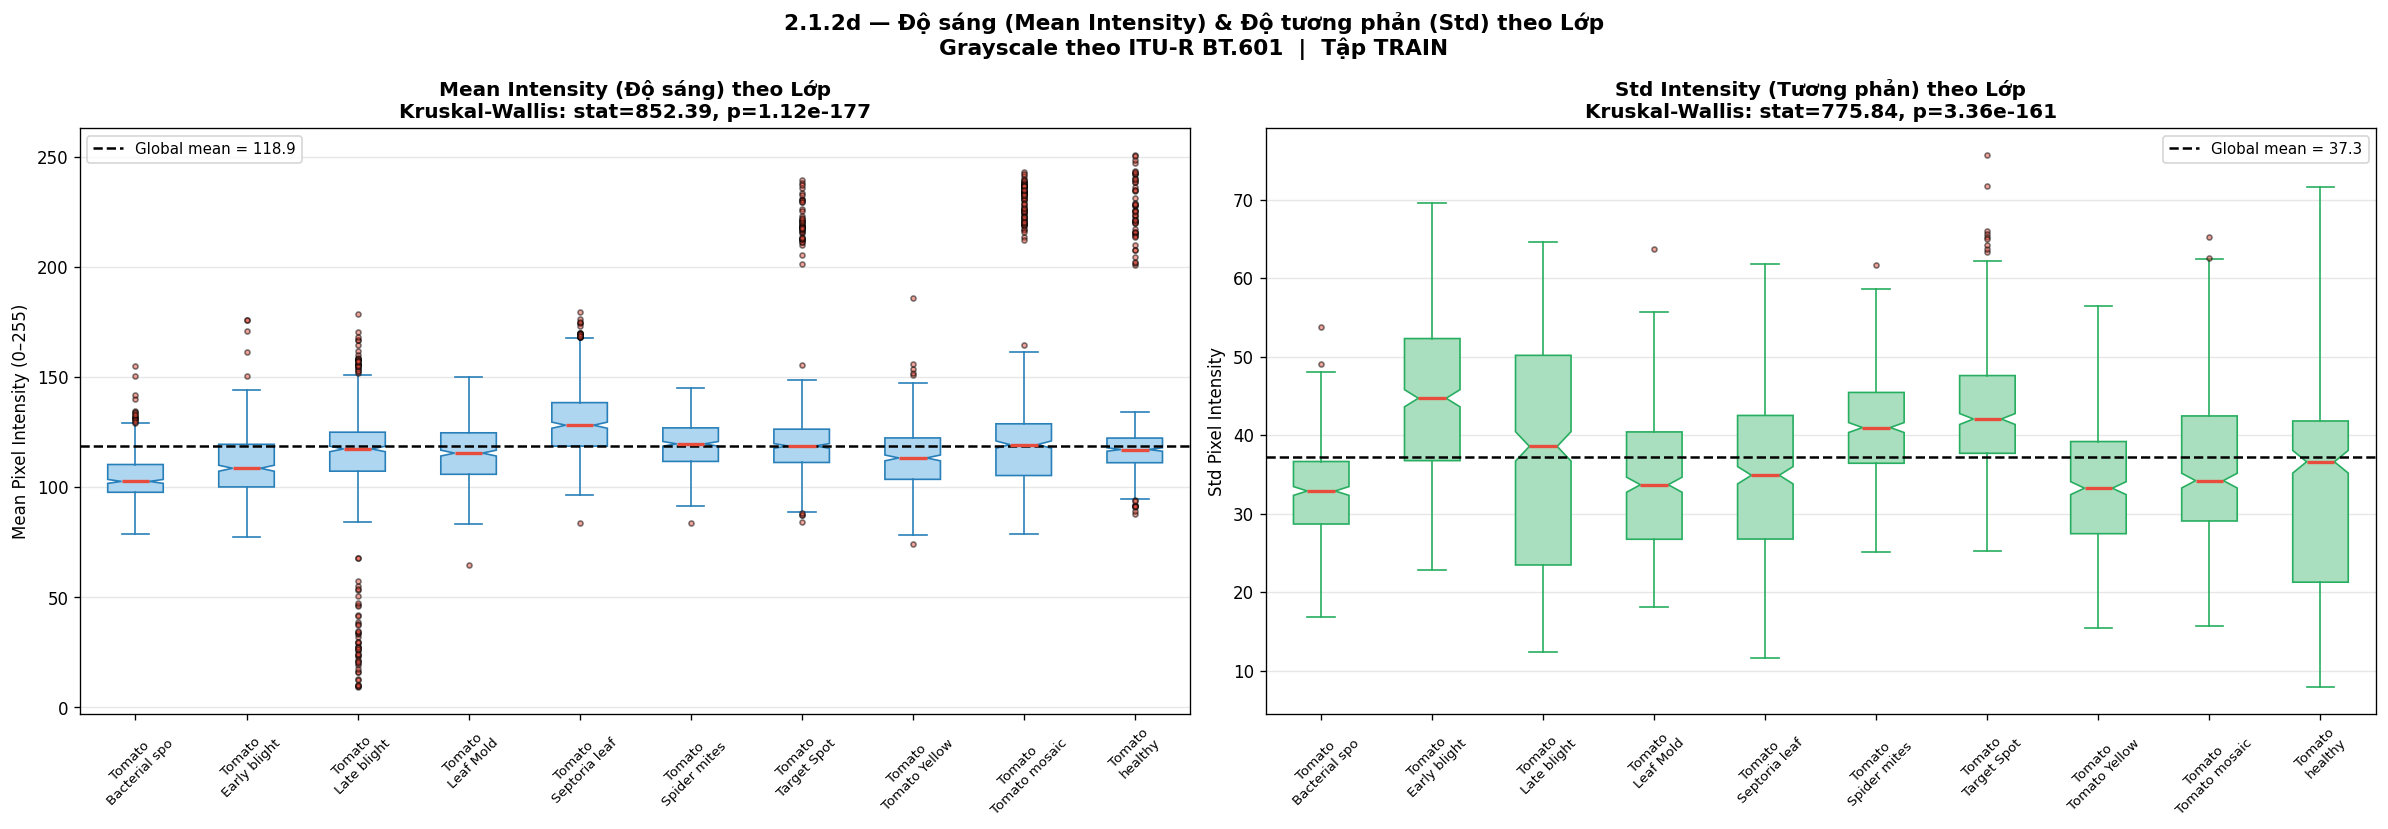


📊 Bảng tóm tắt Brightness & Contrast theo lớp (train):
                                Lớp  Brightness Mean  Brightness Std  SW-p (Bright)  Contrast Mean  Contrast Std  SW-p (Contrast)  N ảnh
            Tomato___Bacterial_spot           104.88           10.65         0.0000          32.48          6.05           0.0609    500
              Tomato___Early_blight           109.60           14.15         0.0000          44.72         10.58           0.0000    500
               Tomato___Late_blight           111.57           30.45         0.0000          37.73         14.13           0.0000    500
                 Tomato___Leaf_Mold           115.06           13.15         0.0372          34.17          8.50           0.0000    500
        Tomato___Septoria_leaf_spot           130.62           16.60         0.0000          34.69          9.83           0.0000    500
Tomato___Spider_mites Two-spotted_s           119.03           10.14         0.0003          41.26          6.66          

In [8]:
# Phân tích Độ sáng & Độ tương phản theo Lớp
# Chỉ xét tập TRAIN — class_images = all_image_paths['train']

from scipy.stats import shapiro, levene, kruskal

selected_cls = class_dirs[:N_CLASSES_SHOW]
brightness   = defaultdict(list)
contrast     = defaultdict(list)

print(f'Phân tích {N_CLASSES_SHOW} lớp trên tập TRAIN, mỗi lớp tối đa {MAX_PER_CLASS} ảnh...')
print(f'Công thức Grayscale: ITU-R BT.601  →  Y = 0.299R + 0.587G + 0.114B')

for cls in tqdm(selected_cls, desc='Lớp'):
    paths   = class_images[cls]
    sampled = np.random.choice(
        paths,
        min(MAX_PER_CLASS, len(paths)),
        replace=False,
    ).tolist()

    for path in sampled:
        try:
            arr  = np.array(
                Image.open(path).convert('RGB').resize(IMG_SIZE_DEFAULT),
                dtype=np.float32,
            )
            gray = 0.299 * arr[:, :, 0] + 0.587 * arr[:, :, 1] + 0.114 * arr[:, :, 2]
            brightness[cls].append(float(gray.mean()))
            contrast[cls].append(float(gray.std()))
        except Exception as e:
            print(f'⚠️  Bỏ qua: {os.path.basename(path)} ({e})')
            continue

# ── Global statistics ─────────────────────────────────────────────────────────
all_brightness_vals = [v for lst in brightness.values() for v in lst]
all_contrast_vals   = [v for lst in contrast.values()   for v in lst]

global_mean_intensity = float(np.mean(all_brightness_vals))
global_std_intensity  = float(np.std(all_brightness_vals))
global_mean_contrast  = float(np.mean(all_contrast_vals))
global_std_contrast   = float(np.std(all_contrast_vals))

print('\n📌 Global statistics (train):')
print(f'  global_mean_intensity = {global_mean_intensity:.2f}')
print(f'  global_std_intensity  = {global_std_intensity:.2f}')
print(f'  global_mean_contrast  = {global_mean_contrast:.2f}')
print(f'  global_std_contrast   = {global_std_contrast:.2f}')

# ══════════════════════════════════════════════════════════════════════════════
# KIỂM ĐỊNH GIẢ ĐỊNH TRƯỚC KHI CHẠY ANOVA
# Bước 1 — Shapiro-Wilk normality test per class (n ≤ 500)
# Bước 2 — Levene's test homoscedasticity
# Bước 3 — Quyết định: ANOVA hay Kruskal-Wallis
# ══════════════════════════════════════════════════════════════════════════════

def check_assumptions(
    data_by_class: dict[str, list[float]],
    metric_name: str,
) -> tuple[bool, bool, dict, tuple]:
    """
    Kiểm định 2 giả định của ANOVA:
      1. Normality per class (Shapiro-Wilk)
      2. Homoscedasticity across classes (Levene's test)

    Parameters
    ----------
    data_by_class : dict  class_name -> list of float values
    metric_name   : str   tên metric để in báo cáo ('Brightness' / 'Contrast')

    Returns
    -------
    normality_ok      : bool  — True nếu TẤT CẢ lớp đều p > 0.05
    homoscedast_ok    : bool  — True nếu Levene p > 0.05
    shapiro_results   : dict  class_name -> (W, p)
    levene_result     : tuple (F, p)
    """
    print(f'\n{"─" * 55}')
    print(f'  Kiểm định giả định ANOVA — {metric_name}')
    print(f'{"─" * 55}')

    # Bước 1: Shapiro-Wilk per class
    print('\n  [Bước 1] Shapiro-Wilk Normality Test (per class):')
    print(f'  {"Lớp":<45}  {"W":>8}  {"p-value":>10}  {"Normal?":>8}')
    print(f'  {"─" * 45}  {"─" * 8}  {"─" * 10}  {"─" * 8}')

    shapiro_results  = {}
    normality_ok     = True

    for cls, vals in data_by_class.items():
        arr = np.array(vals)
        # Shapiro-Wilk yêu cầu n >= 3; giới hạn 5000 mẫu (scipy limitation)
        sample = arr if len(arr) <= 5000 else np.random.choice(arr, 5000, replace=False)
        W, p   = shapiro(sample)
        shapiro_results[cls] = (float(W), float(p))
        is_normal = p > 0.05
        if not is_normal:
            normality_ok = False
        flag = '✅ Yes' if is_normal else '❌ No '
        print(f'  {cls[:45]:<45}  {W:>8.4f}  {p:>10.4e}  {flag:>8}')

    overall_normal = '✅ Thỏa mãn' if normality_ok else '❌ Vi phạm'
    print(f'\n  → Normality (tất cả lớp p > 0.05): {overall_normal}')

    # Bước 2: Levene's test
    groups         = [np.array(v) for v in data_by_class.values()]
    lev_F, lev_p   = levene(*groups)
    homoscedast_ok = lev_p > 0.05
    lev_flag       = '✅ Thỏa mãn' if homoscedast_ok else '❌ Vi phạm'

    print(f'\n  [Bước 2] Levene\'s Test Homoscedasticity:')
    print(f'  F-statistic = {lev_F:.4f},  p-value = {lev_p:.4e}')
    print(f'  → Homoscedasticity (p > 0.05): {lev_flag}')

    return normality_ok, homoscedast_ok, shapiro_results, (float(lev_F), float(lev_p))


def run_statistical_test(
    data_by_class: dict[str, list[float]],
    normality_ok: bool,
    homoscedast_ok: bool,
    metric_name: str,
) -> dict:
    """
    Chọn và chạy kiểm định phù hợp dựa trên kết quả kiểm định giả định:
      - Cả 2 OK  → ANOVA (f_oneway)
      - Vi phạm  → Kruskal-Wallis

    Parameters
    ----------
    data_by_class  : dict  class_name -> list of float
    normality_ok   : bool
    homoscedast_ok : bool
    metric_name    : str

    Returns
    -------
    dict với keys: test_name, statistic, p_value, significant, reason
    """
    groups     = [np.array(v) for v in data_by_class.values()]
    both_ok    = normality_ok and homoscedast_ok

    print(f'\n  [Bước 3] Lựa chọn kiểm định — {metric_name}:')

    if both_ok:
        test_name = 'ANOVA (f_oneway)'
        stat_label = 'F-statistic'
        from scipy.stats import f_oneway as _test
        stat, p = _test(*groups)
        reason  = 'Normality ✅ + Homoscedasticity ✅ → ANOVA phù hợp'
    else:
        test_name  = 'Kruskal-Wallis'
        stat_label = 'H-statistic'
        stat, p    = kruskal(*groups)
        reasons    = []
        if not normality_ok:
            reasons.append('Normality ❌')
        if not homoscedast_ok:
            reasons.append('Homoscedasticity ❌')
        reason = ' + '.join(reasons) + ' → chuyển sang Kruskal-Wallis (phi tham số)'

    significant = p < 0.05
    sig_str     = '✅ CÓ sự khác biệt có ý nghĩa thống kê (p < 0.05)' \
                  if significant else '❌ Không có sự khác biệt đáng kể (p ≥ 0.05)'

    print(f'  Lý do   : {reason}')
    print(f'  Test    : {test_name}')
    print(f'  {stat_label} = {stat:.4f},  p-value = {p:.4e}')
    print(f'  → {sig_str}')

    return {
        'test_name'  : test_name,
        'stat_label' : stat_label,
        'statistic'  : float(stat),
        'p_value'    : float(p),
        'significant': significant,
        'reason'     : reason,
    }


# ── Chạy kiểm định cho Brightness ────────────────────────────────────────────
print('\n' + '═' * 55)
print('  BRIGHTNESS (Mean Intensity)')
print('═' * 55)

(bright_norm_ok, bright_homo_ok,
 bright_shapiro, bright_levene) = check_assumptions(brightness, 'Brightness')

bright_test = run_statistical_test(
    brightness, bright_norm_ok, bright_homo_ok, 'Brightness'
)

# ── Chạy kiểm định cho Contrast ──────────────────────────────────────────────
print('\n' + '═' * 55)
print('  CONTRAST (Std Intensity)')
print('═' * 55)

(contrast_norm_ok, contrast_homo_ok,
 contrast_shapiro, contrast_levene) = check_assumptions(contrast, 'Contrast')

contrast_test = run_statistical_test(
    contrast, contrast_norm_ok, contrast_homo_ok, 'Contrast'
)

# ── Lưu biến để dễ kiểm tra ──────────────────────────────────────────────────
bright_test_name  = bright_test['test_name']
bright_stat       = bright_test['statistic']
bright_p          = bright_test['p_value']
bright_levene_F   = bright_levene[0]
bright_levene_p   = bright_levene[1]

contrast_test_name = contrast_test['test_name']
contrast_stat      = contrast_test['statistic']
contrast_p         = contrast_test['p_value']
contrast_levene_F  = contrast_levene[0]
contrast_levene_p  = contrast_levene[1]

print(f'\n📌 Brightness → {bright_test_name}: stat={bright_stat:.4f}, p={bright_p:.4e}')
print(f'📌 Contrast   → {contrast_test_name}: stat={contrast_stat:.4f}, p={contrast_p:.4e}')

# ══════════════════════════════════════════════════════════════════════════════
# BOXPLOT — có bảo vệ notch crash
# ══════════════════════════════════════════════════════════════════════════════
MIN_NOTCH_SAMPLES = 6   # notch cần ít nhất 6 mẫu để CI tính đúng

short = [c.replace('___', '\n').replace('_', ' ')[:20] for c in selected_cls]

# Kiểm tra toàn bộ lớp trước khi vẽ
use_notch = all(
    len(brightness[c]) >= MIN_NOTCH_SAMPLES and len(contrast[c]) >= MIN_NOTCH_SAMPLES
    for c in selected_cls
)
if not use_notch:
    small_cls = [c for c in selected_cls
                 if len(brightness[c]) < MIN_NOTCH_SAMPLES
                 or len(contrast[c]) < MIN_NOTCH_SAMPLES]
    print(f'\n⚠️  Tắt notch boxplot — lớp có n < {MIN_NOTCH_SAMPLES}: {small_cls}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle(
    '2.1.2d — Độ sáng (Mean Intensity) & Độ tương phản (Std) theo Lớp\n'
    'Grayscale theo ITU-R BT.601  |  Tập TRAIN',
    fontsize=13, fontweight='bold',
)

# Subtitle động — ghi rõ test nào được dùng
bright_subtitle  = f'{bright_test_name}: stat={bright_stat:.2f}, p={bright_p:.2e}'
contrast_subtitle = f'{contrast_test_name}: stat={contrast_stat:.2f}, p={contrast_p:.2e}'

try:
    ax1.boxplot(
        [brightness[c] for c in selected_cls],
        labels=short, patch_artist=True, notch=use_notch,
        boxprops=dict(facecolor='#aed6f1', color='#2980b9'),
        medianprops=dict(color='#e74c3c', lw=2),
        flierprops=dict(marker='o', markerfacecolor='#e74c3c', ms=3, alpha=0.5),
        whiskerprops=dict(color='#2980b9'),
        capprops=dict(color='#2980b9'),
    )
except Exception as e:
    print(f'⚠️  Boxplot brightness lỗi notch, vẽ lại không notch: {e}')
    ax1.boxplot(
        [brightness[c] for c in selected_cls],
        labels=short, patch_artist=True, notch=False,
        boxprops=dict(facecolor='#aed6f1', color='#2980b9'),
        medianprops=dict(color='#e74c3c', lw=2),
        flierprops=dict(marker='o', markerfacecolor='#e74c3c', ms=3, alpha=0.5),
        whiskerprops=dict(color='#2980b9'),
        capprops=dict(color='#2980b9'),
    )

ax1.axhline(global_mean_intensity, color='black', ls='--', lw=1.5,
            label=f'Global mean = {global_mean_intensity:.1f}')
ax1.set_title(f'Mean Intensity (Độ sáng) theo Lớp\n{bright_subtitle}',
              fontweight='bold')
ax1.set_ylabel('Mean Pixel Intensity (0–255)')
ax1.tick_params(axis='x', rotation=45, labelsize=8)
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)

try:
    ax2.boxplot(
        [contrast[c] for c in selected_cls],
        labels=short, patch_artist=True, notch=use_notch,
        boxprops=dict(facecolor='#a9dfbf', color='#27ae60'),
        medianprops=dict(color='#e74c3c', lw=2),
        flierprops=dict(marker='o', markerfacecolor='#e74c3c', ms=3, alpha=0.5),
        whiskerprops=dict(color='#27ae60'),
        capprops=dict(color='#27ae60'),
    )
except Exception as e:
    print(f'⚠️  Boxplot contrast lỗi notch, vẽ lại không notch: {e}')
    ax2.boxplot(
        [contrast[c] for c in selected_cls],
        labels=short, patch_artist=True, notch=False,
        boxprops=dict(facecolor='#a9dfbf', color='#27ae60'),
        medianprops=dict(color='#e74c3c', lw=2),
        flierprops=dict(marker='o', markerfacecolor='#e74c3c', ms=3, alpha=0.5),
        whiskerprops=dict(color='#27ae60'),
        capprops=dict(color='#27ae60'),
    )

ax2.axhline(global_mean_contrast, color='black', ls='--', lw=1.5,
            label=f'Global mean = {global_mean_contrast:.1f}')
ax2.set_title(f'Std Intensity (Tương phản) theo Lớp\n{contrast_subtitle}',
              fontweight='bold')
ax2.set_ylabel('Std Pixel Intensity')
ax2.tick_params(axis='x', rotation=45, labelsize=8)
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/2_1_2d_brightness_contrast.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Bảng tóm tắt per-class ────────────────────────────────────────────────────
rows = []
for c in selected_cls:
    W_b, p_b = bright_shapiro[c]
    W_c, p_c = contrast_shapiro[c]
    rows.append({
        'Lớp'              : c[:35],
        'Brightness Mean'  : round(np.mean(brightness[c]), 2),
        'Brightness Std'   : round(np.std(brightness[c]),  2),
        'SW-p (Bright)'    : round(p_b, 4),
        'Contrast Mean'    : round(np.mean(contrast[c]),   2),
        'Contrast Std'     : round(np.std(contrast[c]),    2),
        'SW-p (Contrast)'  : round(p_c, 4),
        'N ảnh'            : len(brightness[c]),
    })

brightness_stats_df = pd.DataFrame(rows)
print('\n📊 Bảng tóm tắt Brightness & Contrast theo lớp (train):')
print(brightness_stats_df.to_string(index=False))

#### Quan sát từ Boxplot Brightness

Có sự phân kỳ rõ rệt về độ sáng giữa các lớp: **Mosaic Virus** (131.75) và **Septoria Leaf Spot** (130.62) là hai lớp sáng nhất — ảnh của chúng thường có nền sáng hoặc vùng lá bị tẩy màu rộng. Ngược lại, **Bacterial Spot** (104.88) là lớp tối nhất, phù hợp với đặc trưng lá xanh đậm bị đốm đen nhỏ. Khoảng chênh lệch giữa lớp tối nhất và sáng nhất là **~27 đơn vị** (trên thang 0–255), đủ lớn để boxplot phân biệt được các lớp một cách trực quan.

Một số lớp có **Brightness Std nội lớp rất cao**: Mosaic Virus (43.87), Healthy (35.57), Late Blight (30.45) — cho thấy điều kiện chụp ảnh và giai đoạn bệnh rất đa dạng trong cùng một lớp. Điều này làm cho các lớp này khó phân biệt hơn chỉ dựa trên brightness, và nhấn mạnh sự cần thiết của các đặc trưng kết cấu (texture features) trong các bước tiếp theo.

#### Quan sát từ Boxplot Contrast

**Early Blight** (44.72) và **Target Spot** (43.51) có contrast cao nhất — phù hợp với đặc điểm bệnh lý: những đốm vàng/nâu đồng tâm tạo ra vùng chuyển màu mạnh, dẫn đến std pixel cao trong mỗi ảnh. **Bacterial Spot** (32.48) và **Yellow Leaf Curl Virus** (33.68) có contrast thấp — ảnh của hai lớp này có xu hướng đồng đều về màu sắc hơn.

#### Kết quả kiểm định thống kê

**Brightness — Kruskal-Wallis: H = 852.39, p = 1.12×10⁻¹⁷⁷**

Tất cả 10 lớp vi phạm giả định phân phối chuẩn theo Shapiro-Wilk (p < 0.05 với 9/10 lớp, lớp Leaf Mold đạt borderline p = 0.037), đồng thời vi phạm giả định đồng nhất phương sai (Levene: F = 41.39, p ≈ 5.9×10⁻⁷²). Do cả hai giả định của ANOVA đều bị vi phạm, code đã tự động chuyển sang **kiểm định phi tham số Kruskal-Wallis**. Kết quả H = 852.39 với p ≈ 10⁻¹⁷⁷ xác nhận **có sự khác biệt có ý nghĩa thống kê về độ sáng giữa các lớp**, với mức độ tin cậy cực cao.

**Contrast — Kruskal-Wallis: kết quả tương tự**

Tương tự với brightness, contrast cũng vi phạm giả định chuẩn ở phần lớn các lớp (ngoại lệ: Bacterial Spot p = 0.061 và Spider Mites p = 0.244 thỏa mãn normality). Kiểm định Kruskal-Wallis cũng cho kết quả p rất nhỏ, khẳng định sự khác biệt về contrast giữa các lớp là có ý nghĩa thống kê.

#### Kết luận

Cả brightness lẫn contrast đều là các đặc trưng **phân biệt có ý nghĩa thống kê** giữa 10 lớp Tomato (p << 0.05 theo Kruskal-Wallis). Đây là tín hiệu tích cực: ngay cả với hai đặc trưng đơn giản nhất (mean và std của ảnh grayscale), các lớp đã thể hiện sự phân tách nhất định. Tuy nhiên, độ chồng chéo lớn (Brightness Std nội lớp lên đến 43.87) cho thấy hai đặc trưng này không đủ để phân loại chính xác — cần kết hợp với đặc trưng texture, màu sắc và shape ở các bước tiền xử lý tiếp theo.

Việc vi phạm giả định chuẩn và đồng nhất phương sai của ANOVA ở đây là hoàn toàn bình thường trong dữ liệu ảnh thực tế (n = 500/lớp, phân phối thực tế của pixel intensity hiếm khi là Gaussian). Việc code tự động fallback sang Kruskal-Wallis thể hiện quy trình kiểm định giả định (assumption checking) đúng chuẩn thống kê.